# Notebook 1 — Análisis Exploratorio del Dataset (EDA)
## Proyecto: Análisis de polarización ideológica en redes sociales
### Dataset: PHEME — Rumour Detection and Veracity Classification

**Estructura del dataset:**
```
TratamientoDatosMayo/
  data/
    pheme-rnr-dataset/
      <evento>-all-rnr-threads/
        rumours/ | non-rumours/
          <thread_id>/
            annotation.json
            source-tweets/<id>.json
            reactions/<id>.json
  notebooks/
    01_eda.ipynb   <- este fichero
  results/
```

## 0. Instalacion de dependencias

In [1]:
# Ejecutar solo si no estan instaladas
# import sys
# !{sys.executable} -m pip install pandas numpy matplotlib seaborn wordcloud nltk scikit-learn tqdm

## 1. Imports y configuracion

In [2]:
import os
import json
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

# ---------------------------------------------------------------
# RUTAS — el notebook esta en notebooks/ y los datos en la raiz
# '../' sube un nivel desde notebooks/ hasta TratamientoDatosMayo/
# ---------------------------------------------------------------
BASE_DIR     = os.path.abspath(os.path.join(os.getcwd(), '..'))
PHEME_PATH   = os.path.join(BASE_DIR, 'data', 'pheme-rnr-dataset')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f'Directorio base:     {BASE_DIR}')
print(f'Dataset PHEME:       {PHEME_PATH}')
print(f'Resultados:          {RESULTS_DIR}')
print(f'Dataset procesado:   {PROCESSED_DIR}')
print(f'Dataset existe:      {os.path.exists(PHEME_PATH)}')
print('\nImports OK')

Directorio base:     C:\Users\danie\PycharmProjects\TratamientoDatosMayo
Dataset PHEME:       C:\Users\danie\PycharmProjects\TratamientoDatosMayo\data\pheme-rnr-dataset
Resultados:          C:\Users\danie\PycharmProjects\TratamientoDatosMayo\results
Dataset procesado:   C:\Users\danie\PycharmProjects\TratamientoDatosMayo\data\processed
Dataset existe:      True

Imports OK


## 2. Carga y parseo del dataset PHEME

In [3]:
def parse_annotation(annotation: dict, rumour_type: str) -> str:
    """
    Determina la etiqueta de veracidad a partir del annotation.json.

    Non-rumours: {"is_rumour": "nonrumour"} -> 'non-rumour'
    Rumours:     {"is_rumour": "rumour", "misinformation": 0|1, "true": "0"|"1"}
                 -> 'true' | 'false' | 'unverified'
    """
    if rumour_type == 'non-rumours':
        return 'non-rumour'

    misinformation = annotation.get('misinformation', None)
    true_val       = annotation.get('true', None)

    if misinformation is None and true_val is None:
        return 'unverified'

    try:
        mis = int(misinformation) if misinformation is not None else None
        tru = int(true_val)       if true_val       is not None else None
    except (ValueError, TypeError):
        return 'unverified'

    if tru == 1:
        return 'true'
    elif mis == 1:
        return 'false'
    else:
        return 'unverified'


def parse_pheme_dataset(base_path: str) -> pd.DataFrame:
    """
    Parsea la estructura de directorios del dataset PHEME.
    Retorna un DataFrame con una fila por tweet (source + reactions).
    """
    records = []

    if not os.path.exists(base_path):
        raise FileNotFoundError(
            f'Dataset no encontrado en: {base_path}\n'
            f'Comprueba que la carpeta pheme-rnr-dataset esta en: {os.path.dirname(base_path)}'
        )

    events = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d)) and 'rnr-threads' in d
    ])
    print(f'Eventos encontrados ({len(events)}):')
    for e in events:
        print(f'  - {e}')
    print()

    for event in tqdm(events, desc='Procesando eventos'):
        event_name = event.replace('-all-rnr-threads', '')
        event_path = os.path.join(base_path, event)

        for rumour_type in ['rumours', 'non-rumours']:
            rt_path = os.path.join(event_path, rumour_type)
            if not os.path.exists(rt_path):
                continue

            thread_ids = [
                d for d in os.listdir(rt_path)
                if os.path.isdir(os.path.join(rt_path, d)) and not d.startswith('.')
            ]

            for thread_id in thread_ids:
                thread_path = os.path.join(rt_path, thread_id)

                # Leer annotation.json
                ann_path   = os.path.join(thread_path, 'annotation.json')
                annotation = {}
                if os.path.exists(ann_path):
                    try:
                        with open(ann_path, 'r', encoding='utf-8') as f:
                            annotation = json.load(f)
                    except Exception:
                        pass

                veracity = parse_annotation(annotation, rumour_type)

                # Source tweet
                src_path = os.path.join(thread_path, 'source-tweets')
                if os.path.exists(src_path):
                    for fname in os.listdir(src_path):
                        if fname.endswith('.json') and not fname.startswith('.'):
                            try:
                                with open(os.path.join(src_path, fname), 'r', encoding='utf-8') as f:
                                    tweet = json.load(f)
                                records.append({
                                    'tweet_id':       tweet.get('id_str', fname.replace('.json', '')),
                                    'text':           tweet.get('text', ''),
                                    'event':          event_name,
                                    'thread_id':      thread_id,
                                    'tweet_type':     'source',
                                    'rumour_type':    rumour_type,
                                    'veracity':       veracity,
                                    'retweet_count':  tweet.get('retweet_count', 0),
                                    'favorite_count': tweet.get('favorite_count', 0),
                                    'user_followers': tweet.get('user', {}).get('followers_count', 0),
                                })
                            except Exception:
                                pass

                # Reactions
                react_path = os.path.join(thread_path, 'reactions')
                if os.path.exists(react_path):
                    for fname in os.listdir(react_path):
                        if fname.endswith('.json') and not fname.startswith('.'):
                            try:
                                with open(os.path.join(react_path, fname), 'r', encoding='utf-8') as f:
                                    tweet = json.load(f)
                                records.append({
                                    'tweet_id':       tweet.get('id_str', fname.replace('.json', '')),
                                    'text':           tweet.get('text', ''),
                                    'event':          event_name,
                                    'thread_id':      thread_id,
                                    'tweet_type':     'reaction',
                                    'rumour_type':    rumour_type,
                                    'veracity':       veracity,
                                    'retweet_count':  tweet.get('retweet_count', 0),
                                    'favorite_count': tweet.get('favorite_count', 0),
                                    'user_followers': tweet.get('user', {}).get('followers_count', 0),
                                })
                            except Exception:
                                pass

    return pd.DataFrame(records)


df_raw = parse_pheme_dataset(PHEME_PATH)
print(f'\nDataset cargado: {len(df_raw):,} tweets')
df_raw.head()

Eventos encontrados (9):
  - charliehebdo-all-rnr-threads
  - ebola-essien-all-rnr-threads
  - ferguson-all-rnr-threads
  - germanwings-crash-all-rnr-threads
  - gurlitt-all-rnr-threads
  - ottawashooting-all-rnr-threads
  - prince-toronto-all-rnr-threads
  - putinmissing-all-rnr-threads
  - sydneysiege-all-rnr-threads



Procesando eventos: 100%|██████████| 9/9 [00:08<00:00,  1.01it/s]


Dataset cargado: 105,354 tweets


,tweet_id,text,event,thread_id,tweet_type,rumour_type,veracity,retweet_count,favorite_count,user_followers
0,552783238415265792,"Breaking: At least 10 dead, 5 injured after tO...",charliehebdo,552783238415265792,source,rumours,true,159,14,1628
1,552787794503143424,@H_E_Samuel @George_Berridge @michael_taggart ...,charliehebdo,552783238415265792,reaction,rumours,true,1,0,40
2,552789647966109696,@H_E_Samuel Hi Henry would you be willing to g...,charliehebdo,552783238415265792,reaction,rumours,true,0,0,375
3,552791411053973505,@H_E_Samuel @H_E_Samuel please call them terro...,charliehebdo,552783238415265792,reaction,rumours,true,0,1,17
4,552793152390955009,@H_E_Samuel French govt needs to take strict a...,charliehebdo,552783238415265792,reaction,rumours,true,0,0,54


## 3. Descripcion general del dataset

In [4]:
print('=' * 60)
print('DESCRIPCION GENERAL DEL DATASET')
print('=' * 60)
print(f'\nNº de tweets (instancias): {len(df_raw):,}')
print(f'Nº de variables:           {df_raw.shape[1]}')
print(f'Nº de eventos:             {df_raw["event"].nunique()}')
print(f'Nº de hilos unicos:        {df_raw["thread_id"].nunique():,}')
print(f'\nVariables: {list(df_raw.columns)}')
print()
print('TIPOS DE DATOS:')
print(df_raw.dtypes)
print()
print('VALORES NULOS:')
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No hay valores nulos')
print()
print(f'TEXTOS DUPLICADOS: {df_raw.duplicated(subset=["text"]).sum():,}')

DESCRIPCION GENERAL DEL DATASET

Nº de tweets (instancias): 105,354
Nº de variables:           10
Nº de eventos:             9
Nº de hilos unicos:        6,425

Variables: ['tweet_id', 'text', 'event', 'thread_id', 'tweet_type', 'rumour_type', 'veracity', 'retweet_count', 'favorite_count', 'user_followers']

TIPOS DE DATOS:
tweet_id            str
text                str
event               str
thread_id           str
tweet_type          str
rumour_type         str
veracity            str
retweet_count     int64
favorite_count    int64
user_followers    int64
dtype: object

VALORES NULOS:
No hay valores nulos

TEXTOS DUPLICADOS: 1,416


In [5]:
print('ESTADISTICAS BASICAS (variables numericas):')
print(df_raw[['retweet_count', 'favorite_count', 'user_followers']].describe().round(1).to_string())
print('\nTWEETS POR TIPO (source vs reaction):')
print(df_raw['tweet_type'].value_counts().to_string())
print('\nTWEETS POR EVENTO:')
print(df_raw.groupby('event').size().sort_values(ascending=False).to_string())

ESTADISTICAS BASICAS (variables numericas):
       retweet_count  favorite_count  user_followers
count       105354.0        105354.0        105354.0
mean            26.3            14.6         78017.3
std            513.9           551.7        850323.3
min              0.0             0.0             0.0
25%              0.0             0.0           107.0
50%              0.0             0.0           450.0
75%              0.0             1.0          1586.0
max          99524.0        149783.0      25303087.0

TWEETS POR TIPO (source vs reaction):
tweet_type
reaction    98929
source       6425

TWEETS POR EVENTO:
event
charliehebdo         38268
ferguson             24175
sydneysiege          23996
ottawashooting       12284
germanwings-crash     4489
prince-toronto         902
putinmissing           835
ebola-essien           226
gurlitt                179


## 4. Distribucion de clases

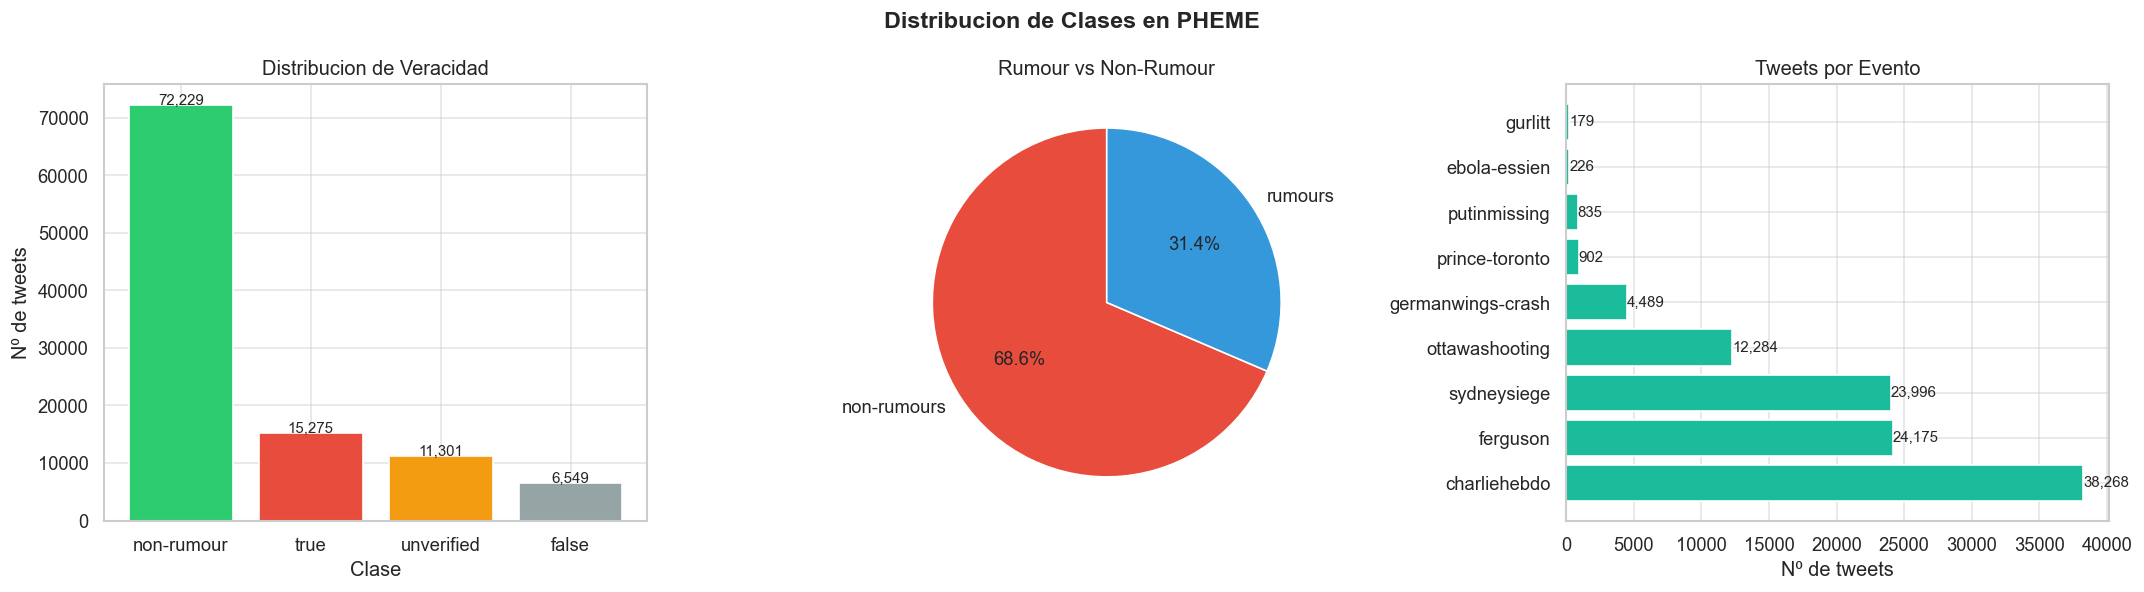

Guardado en: C:\Users\danie\PycharmProjects\TratamientoDatosMayo\results


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion de Clases en PHEME', fontsize=14, fontweight='bold')

# Veracidad
ver_counts = df_raw['veracity'].value_counts()
colors_ver = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
bars = axes[0].bar(ver_counts.index, ver_counts.values, color=colors_ver[:len(ver_counts)])
axes[0].set_title('Distribucion de Veracidad')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Nº de tweets')
for bar, val in zip(bars, ver_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 50,
                 f'{val:,}', ha='center', fontsize=9)

# Rumour vs Non-rumour
rt_counts = df_raw['rumour_type'].value_counts()
axes[1].pie(rt_counts.values, labels=rt_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#3498db'], startangle=90)
axes[1].set_title('Rumour vs Non-Rumour')

# Tweets por evento
event_counts = df_raw['event'].value_counts()
axes[2].barh(event_counts.index, event_counts.values, color='#1abc9c')
axes[2].set_title('Tweets por Evento')
axes[2].set_xlabel('Nº de tweets')
for i, val in enumerate(event_counts.values):
    axes[2].text(val + 10, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '01_class_distribution.png'), bbox_inches='tight')
plt.show()
print(f'Guardado en: {RESULTS_DIR}')

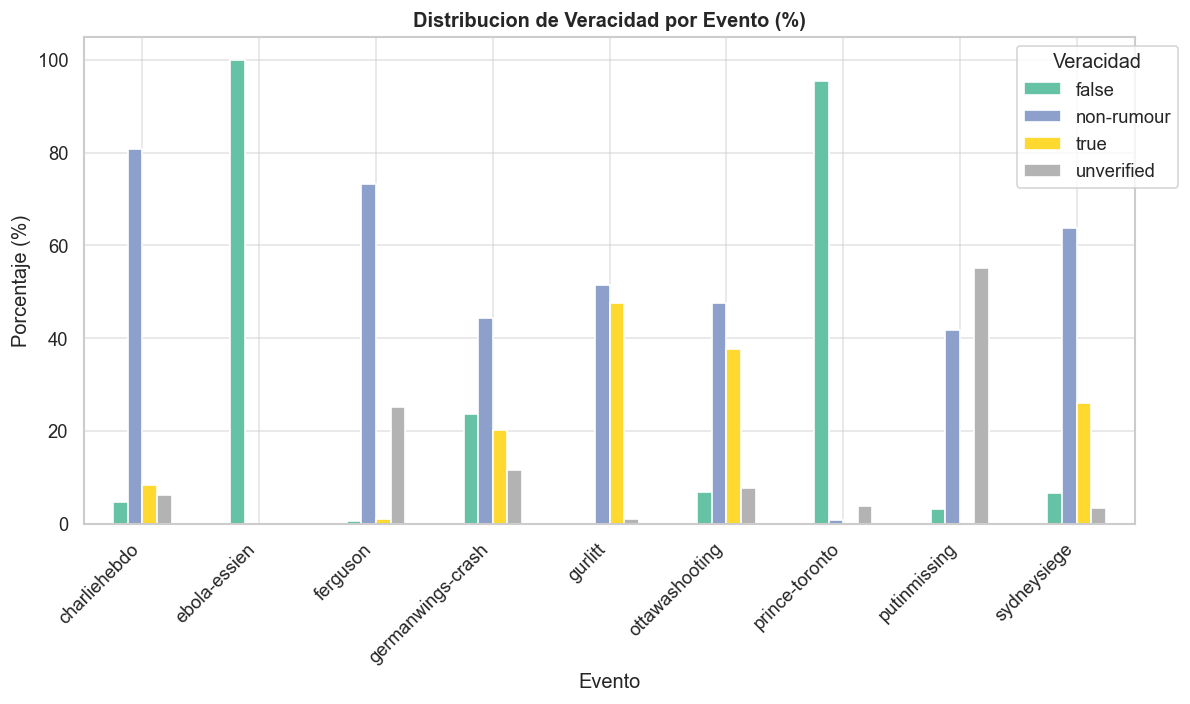

In [7]:
# Distribucion de veracidad por evento
pivot_event = pd.crosstab(df_raw['event'], df_raw['veracity'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
pivot_event.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Distribucion de Veracidad por Evento (%)', fontweight='bold')
ax.set_xlabel('Evento')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Veracidad', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_veracity_by_event.png'), bbox_inches='tight')
plt.show()

## 5. Analisis de longitud del texto

In [8]:
df_raw['text_length'] = df_raw['text'].str.len()
df_raw['word_count']  = df_raw['text'].str.split().str.len()

print('LONGITUD DE TEXTO POR CLASE DE VERACIDAD:')
print(df_raw.groupby('veracity')[['text_length', 'word_count']].agg(['mean', 'median']).round(1).to_string())
print('\nLONGITUD POR TIPO DE TWEET:')
print(df_raw.groupby('tweet_type')[['text_length', 'word_count']].mean().round(1).to_string())

LONGITUD DE TEXTO POR CLASE DE VERACIDAD:
           text_length        word_count       
                  mean median       mean median
veracity                                       
false             90.8   95.0       13.2   14.0
non-rumour        96.9  105.0       14.2   15.0
true              92.4   99.0       13.6   14.0
unverified        97.9  106.0       14.7   15.0

LONGITUD POR TIPO DE TWEET:
            text_length  word_count
tweet_type                         
reaction           94.6        14.0
source            118.0        16.2


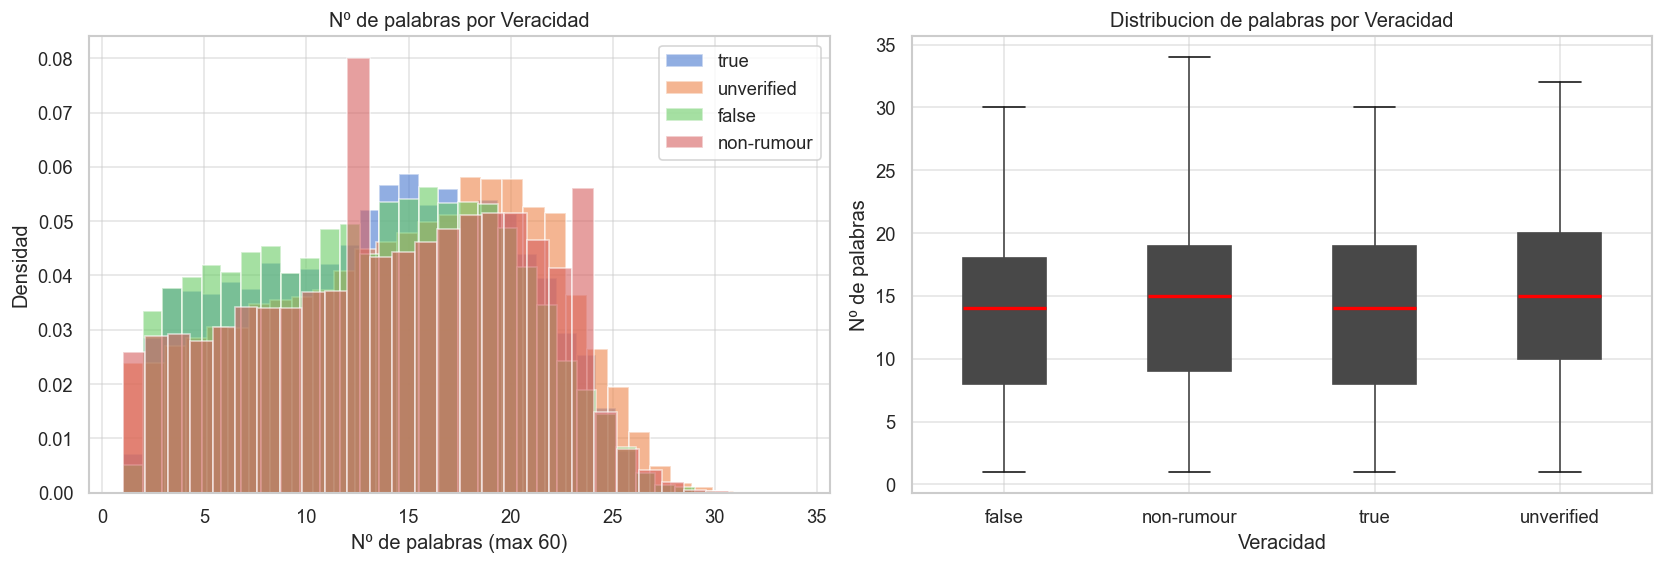

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucion de Longitud del Texto', fontsize=13, fontweight='bold')

for ver in df_raw['veracity'].unique():
    data = df_raw[df_raw['veracity'] == ver]['word_count'].clip(upper=60)
    axes[0].hist(data, bins=30, alpha=0.6, label=ver, density=True)
axes[0].set_title('Nº de palabras por Veracidad')
axes[0].set_xlabel('Nº de palabras (max 60)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

df_raw.boxplot(column='word_count', by='veracity', ax=axes[1],
               patch_artist=True, medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Distribucion de palabras por Veracidad')
axes[1].set_xlabel('Veracidad')
axes[1].set_ylabel('Nº de palabras')
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_text_length.png'), bbox_inches='tight')
plt.show()

## 6. Analisis de texto — Frecuencias y nubes de palabras

In [10]:
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['rt', 'http', 'https', 'amp', 'via', 'co', 'twitter'])

def preprocess_text(text: str) -> list:
    """Limpieza: lowercase, eliminar URLs, menciones, puntuacion y stopwords."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [
        w for w in word_tokenize(text)
        if w not in STOP_WORDS and len(w) > 2
    ]
    return tokens

print('Preprocesando textos...')
df_raw['tokens']     = df_raw['text'].apply(preprocess_text)
df_raw['clean_text'] = df_raw['tokens'].apply(lambda x: ' '.join(x))
print('Hecho.')
print(f'\nEjemplo original: {df_raw["text"].iloc[0]}')
print(f'Ejemplo limpio:   {df_raw["clean_text"].iloc[0]}')

Preprocesando textos...
Hecho.

Ejemplo original: Breaking: At least 10 dead, 5 injured after tO gunman open fire in offices of Charlie  Hebdo,satirical mag that published Mohammed cartoons
Ejemplo limpio:   breaking least dead injured gunman open fire offices charlie hebdosatirical mag published mohammed cartoons


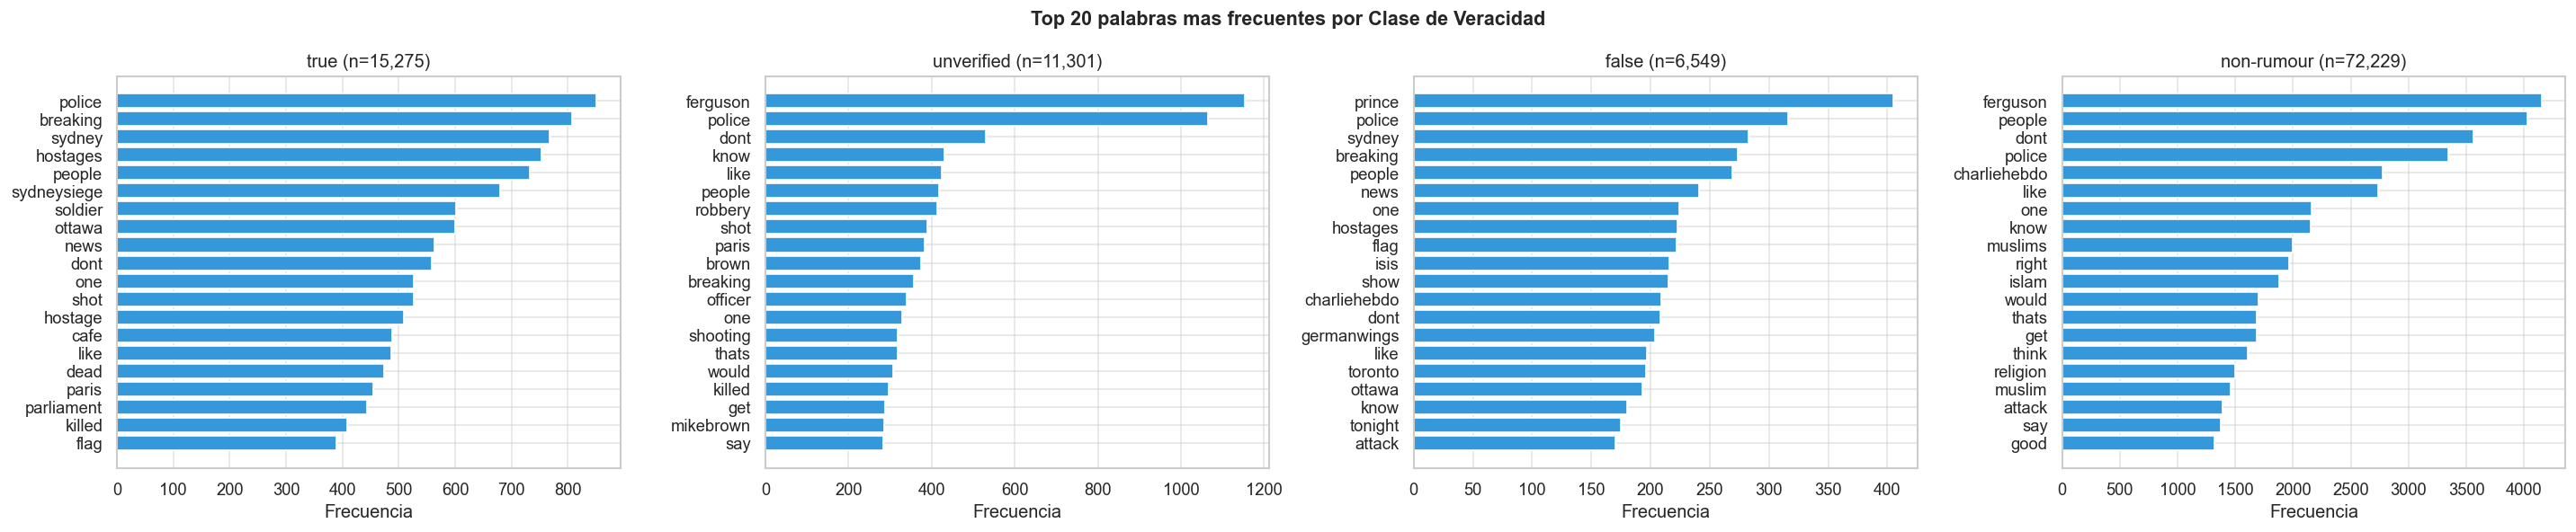

In [11]:
ver_classes = df_raw['veracity'].unique()
n_classes   = len(ver_classes)

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5))
if n_classes == 1:
    axes = [axes]
fig.suptitle('Top 20 palabras mas frecuentes por Clase de Veracidad', fontsize=13, fontweight='bold')

for ax, ver in zip(axes, ver_classes):
    all_tokens  = [t for toks in df_raw[df_raw['veracity'] == ver]['tokens'] for t in toks]
    most_common = Counter(all_tokens).most_common(20)
    words, counts = zip(*most_common)
    ax.barh(words[::-1], counts[::-1], color='#3498db')
    ax.set_title(f'{ver} (n={len(df_raw[df_raw["veracity"]==ver]):,})')
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_top_words.png'), bbox_inches='tight')
plt.show()

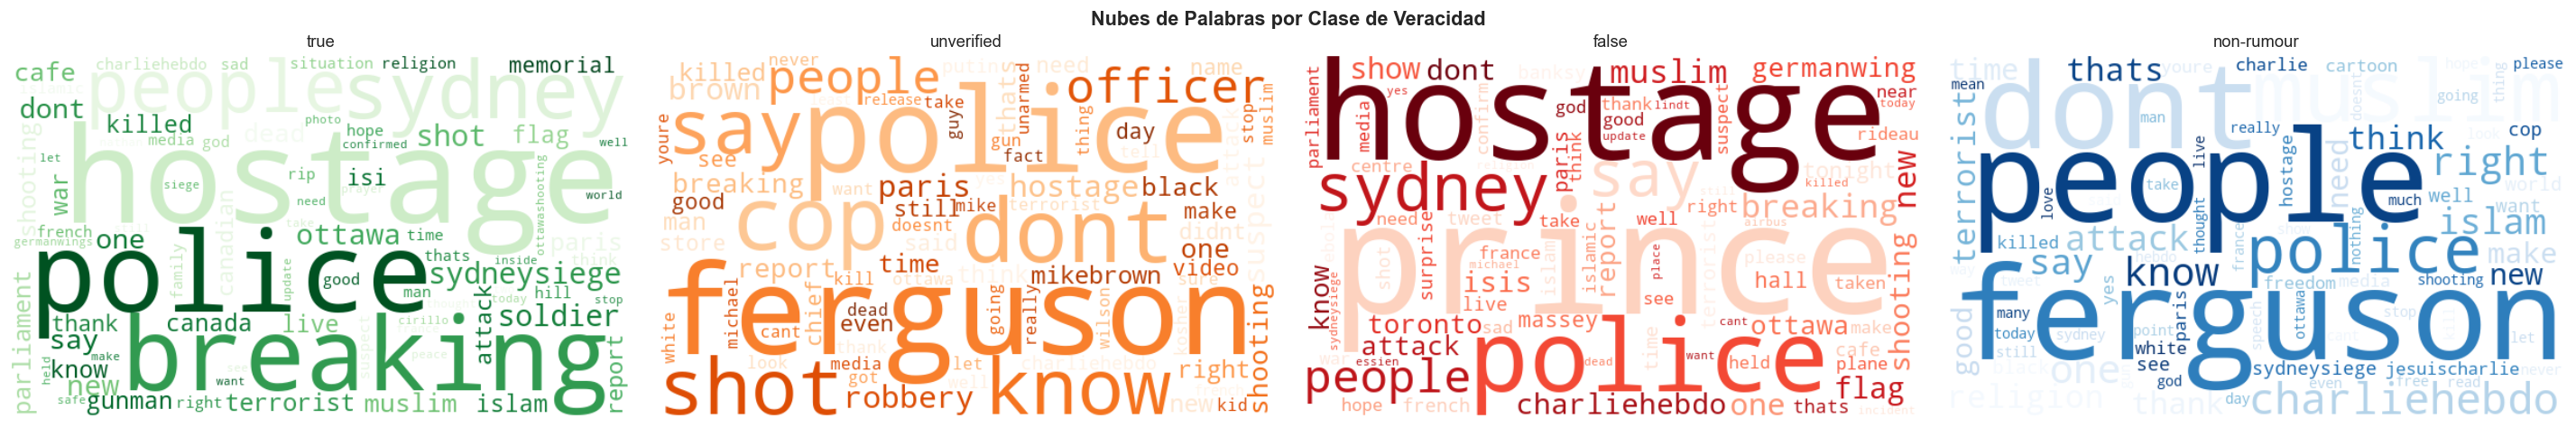

In [12]:
color_maps = {'true': 'Greens', 'false': 'Reds', 'unverified': 'Oranges', 'non-rumour': 'Blues'}

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 4))
if n_classes == 1:
    axes = [axes]
fig.suptitle('Nubes de Palabras por Clase de Veracidad', fontsize=13, fontweight='bold')

for ax, ver in zip(axes, ver_classes):
    corpus = ' '.join(df_raw[df_raw['veracity'] == ver]['clean_text'])
    cmap   = color_maps.get(ver, 'Blues')
    if len(corpus.strip()) > 0:
        wc = WordCloud(width=600, height=350, background_color='white',
                       colormap=cmap, max_words=80, collocations=False).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{ver}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_wordclouds.png'), bbox_inches='tight')
plt.show()

In [13]:
print('EXCLUSIVIDAD LEXICA POR CLASE:')
print('-' * 50)

vocab_by_class = {
    ver: set(t for toks in df_raw[df_raw['veracity'] == ver]['tokens'] for t in toks)
    for ver in ver_classes
}

for ver in ver_classes:
    others    = set().union(*[v for k, v in vocab_by_class.items() if k != ver])
    exclusive = vocab_by_class[ver] - others
    print(f'{ver:15s}: {len(vocab_by_class[ver]):,} palabras unicas | {len(exclusive):,} exclusivas')
    if exclusive:
        print(f'  Ejemplos: {sorted(exclusive)[:10]}')

EXCLUSIVIDAD LEXICA POR CLASE:
--------------------------------------------------
true           : 13,700 palabras unicas | 4,154 exclusivas
  Ejemplos: ['aabbasi', 'aangeven', 'aangifteformulier', 'abatidos', 'abattent', 'abductions', 'abhorrence', 'abigger', 'abknallen', 'ableg']
unverified     : 11,798 palabras unicas | 3,351 exclusivas
  Ejemplos: ['aaaaand', 'aaaand', 'aamp', 'aangekondigd', 'abar', 'abhorrently', 'ablow', 'abolishes', 'aboutam', 'aboutanyhow']
false          : 8,216 palabras unicas | 2,010 exclusivas
  Ejemplos: ['aahja', 'aare', 'aatanke', 'aatma', 'aatmao', 'abarahams', 'abbotprolly', 'abhorloathedespise', 'absolutamente', 'accione']
non-rumour     : 40,530 palabras unicas | 27,514 exclusivas
  Ejemplos: ['aaa', 'aaaaaaand', 'aaaaah', 'aaaah', 'aaah', 'aabu', 'aadhaa', 'aadhe', 'aadmi', 'aadude']


## 7. Analisis de engagement

Source tweets disponibles: 6,425
Reactions (excluidas del analisis de engagement): 98,929



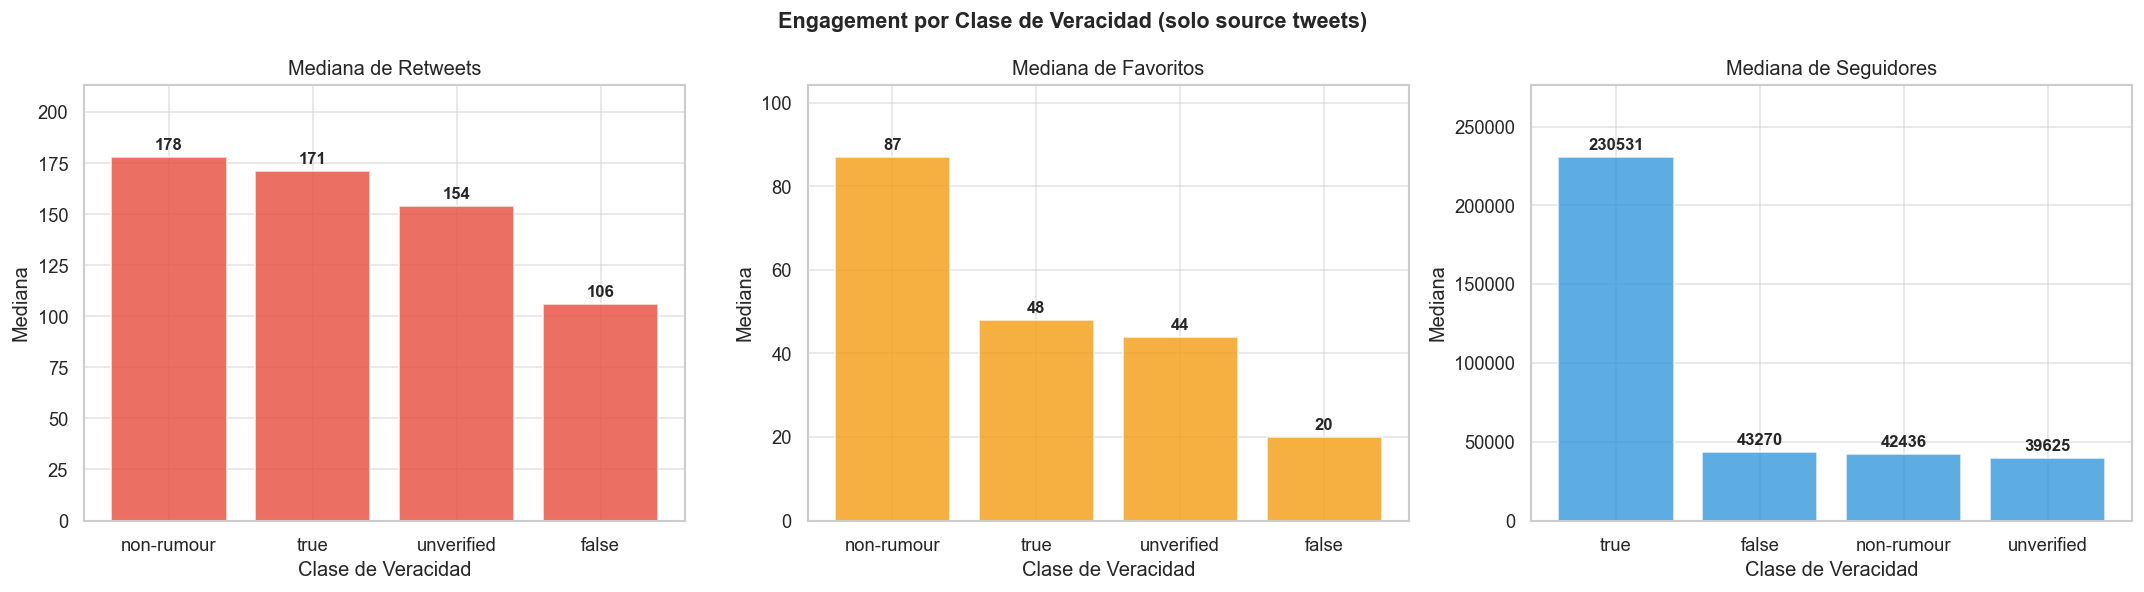

Nota: retweet_count y favorite_count de las reactions estan a 0 en PHEME.
Por eso el analisis se hace solo sobre los tweets originales (source tweets).


In [14]:
# Filtrar solo source tweets (las reactions tienen retweet_count=0 en PHEME)
df_source = df_raw[df_raw['tweet_type'] == 'source'].copy()
print(f'Source tweets disponibles: {len(df_source):,}')
print(f'Reactions (excluidas del analisis de engagement): {len(df_raw[df_raw["tweet_type"]=="reaction"]):,}')
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Engagement por Clase de Veracidad (solo source tweets)', fontsize=13, fontweight='bold')

metrics = [
    ('retweet_count',  'Mediana de Retweets',   '#e74c3c'),
    ('favorite_count', 'Mediana de Favoritos',  '#f39c12'),
    ('user_followers', 'Mediana de Seguidores', '#3498db'),
]

for ax, (col, title, color) in zip(axes, metrics):
    data = df_source.groupby('veracity')[col].median().sort_values(ascending=False)
    bars = ax.bar(data.index, data.values, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Clase de Veracidad')
    ax.set_ylabel('Mediana')
    ax.set_ylim(0, data.values.max() * 1.2 if data.values.max() > 0 else 1)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + data.values.max()*0.02,
                f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '06_engagement.png'), bbox_inches='tight')
plt.show()
print('Nota: retweet_count y favorite_count de las reactions estan a 0 en PHEME.')
print('Por eso el analisis se hace solo sobre los tweets originales (source tweets).')

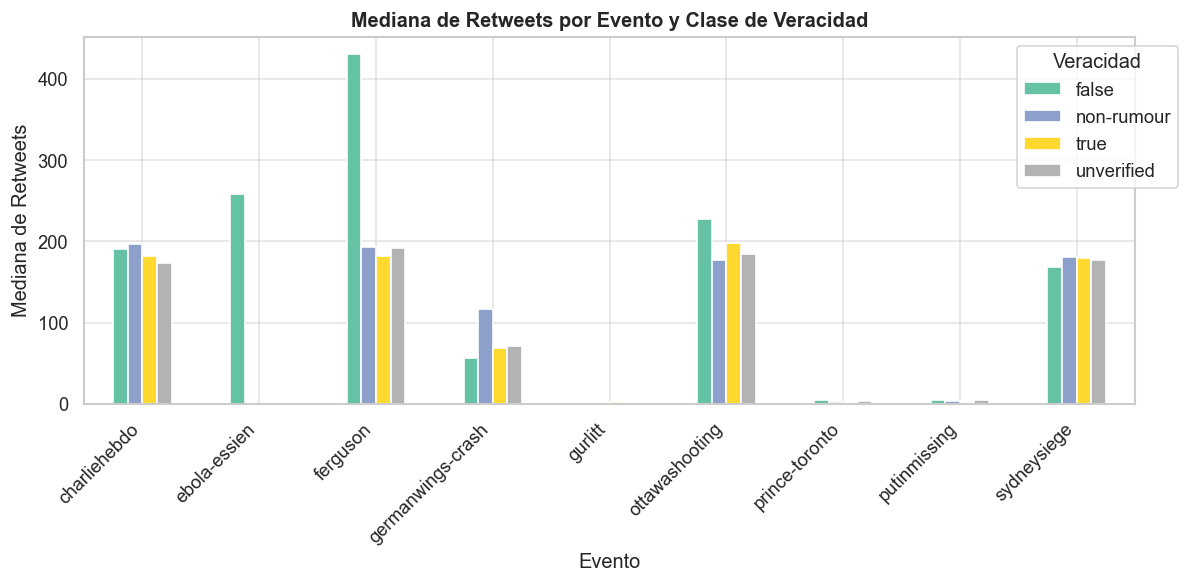

In [15]:
# Retweets por evento (source tweets)
fig, ax = plt.subplots(figsize=(10, 5))
df_source.groupby(['event', 'veracity'])['retweet_count'].median().unstack().plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='white'
)
ax.set_title('Mediana de Retweets por Evento y Clase de Veracidad', fontweight='bold')
ax.set_xlabel('Evento')
ax.set_ylabel('Mediana de Retweets')
ax.legend(title='Veracidad', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_retweets_by_event.png'), bbox_inches='tight')
plt.show()

## 8. Ejemplos representativos por clase

In [16]:
print('EJEMPLOS DE TWEETS POR CLASE DE VERACIDAD')
print('=' * 70)

for ver in ver_classes:
    subset = df_raw[df_raw['veracity'] == ver]
    print(f'\n--- {ver.upper()} ({len(subset):,} tweets) ---')
    samples = subset['text'].sample(min(3, len(subset)), random_state=RANDOM_STATE)
    for i, s in enumerate(samples, 1):
        display_text = s[:160] + '...' if len(s) > 160 else s
        print(f'{i}. {display_text}')

EJEMPLOS DE TWEETS POR CLASE DE VERACIDAD

--- TRUE (15,275 tweets) ---
1. @trixywh I understand...I won't acknowledge the rumor until confirmed by medical or police.
2. "@CBCAlerts: #Ottawa police confirm shooting at War Memorial. Reports say victim may be a soldier." GODDAMNIT NOT IN MY FUCKING BACKYARD &gt;:(
3. @born_too_be @martina__1974 With all due respect, France does not stand with Israel when we deal with the Hamas or Hizballah.

--- UNVERIFIED (11,301 tweets) ---
1. “@AP: BREAKING: Police order shops closed in famed Jewish neighborhood in Paris far from attacks.” This evokes the ghosts of past mistakes.
2. @marcepa49 But that's the FMC, doesn't mean autopilot was engaged.
3. @RalphTooRatchet that's fair but we don't know cops involved in that beating or even all those facts really so I don't see relevance yet

--- FALSE (6,549 tweets) ---
1. @SkyNewsBreak WHERE IS THE SKY CHOPPER?
2. @Canine_Rights You're anti-violence but I can't call for peace? You're anti-bigotry but I ca

## 9. Preparacion del dataset para modelado

In [17]:
# Limpieza final
df_clean = df_raw.copy()
df_clean = df_clean.drop_duplicates(subset=['text'])
df_clean = df_clean.dropna(subset=['text', 'veracity'])
df_clean = df_clean[df_clean['text'].str.len() > 10]
df_clean = df_clean[df_clean['clean_text'].str.len() > 5]
df_clean = df_clean.reset_index(drop=True)

print(f'Dataset original: {len(df_raw):,} tweets')
print(f'Dataset limpio:   {len(df_clean):,} tweets ({len(df_raw)-len(df_clean):,} eliminados)')

# Encodear etiquetas
le_veracity = LabelEncoder()
df_clean['veracity_label'] = le_veracity.fit_transform(df_clean['veracity'])
df_clean['is_rumour']      = (df_clean['rumour_type'] == 'rumours').astype(int)

print('\nMapeo de etiquetas (veracidad):')
for label, idx in zip(le_veracity.classes_, range(len(le_veracity.classes_))):
    count = (df_clean['veracity_label'] == idx).sum()
    print(f'  {idx} -> {label} ({count:,} tweets)')

Dataset original: 105,354 tweets
Dataset limpio:   96,936 tweets (8,418 eliminados)

Mapeo de etiquetas (veracidad):
  0 -> false (5,934 tweets)
  1 -> non-rumour (66,522 tweets)
  2 -> true (14,042 tweets)
  3 -> unverified (10,438 tweets)


In [18]:
# Split estratificado: 70% train / 15% val / 15% test
X = df_clean['text'].values
y = df_clean['veracity_label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('SPLIT TRAIN / VAL / TEST:')
print(f'  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')

print('\nDistribucion de clases en Train:')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {le_veracity.classes_[cls]}: {cnt:,} ({cnt/len(y_train)*100:.1f}%)')

SPLIT TRAIN / VAL / TEST:
  Train: 67,855 (70.0%)
  Val:   14,540 (15.0%)
  Test:  14,541 (15.0%)

Distribucion de clases en Train:
  false: 4,154 (6.1%)
  non-rumour: 46,565 (68.6%)
  true: 9,829 (14.5%)
  unverified: 7,307 (10.8%)


In [19]:
# Guardar dataset procesado y splits
csv_path    = os.path.join(PROCESSED_DIR, 'pheme_clean.csv')
splits_path = os.path.join(PROCESSED_DIR, 'splits.pkl')

df_clean.to_csv(csv_path, index=False)

splits = {
    'X_train':     X_train,
    'X_val':       X_val,
    'X_test':      X_test,
    'y_train':     y_train,
    'y_val':       y_val,
    'y_test':      y_test,
    'le_veracity': le_veracity,
    'label_names': list(le_veracity.classes_),
}

with open(splits_path, 'wb') as f:
    pickle.dump(splits, f)

print('Ficheros guardados:')
print(f'  -> {csv_path}')
print(f'  -> {splits_path}')

Ficheros guardados:
  -> C:\Users\danie\PycharmProjects\TratamientoDatosMayo\data\processed\pheme_clean.csv
  -> C:\Users\danie\PycharmProjects\TratamientoDatosMayo\data\processed\splits.pkl


## 10. Hipotesis de trabajo

Antes de pasar al modelado, dejo explicitadas las hipotesis que guiaran el analisis. Las extraigo de lo que he observado en el EDA:

**H1 - Diferencias lexicas entre clases:** el vocabulario no parece neutral. Los tweets falsos tienden a usar terminos mas alarmistas; los verdaderos, mas descriptivos. Si esto se mantiene, incluso un modelo de bolsa de palabras deberia captarlo parcialmente.

**H2 - Ventaja de los embeddings contextuales:** TF-IDF ignora el orden y el contexto. Sospecho que RoBERTa distinguira mejor rumores de no-rumores, sobre todo en las clases minoritarias como `false` y `unverified`.

**H3 - Engagement como senal de desinformacion:** los source tweets de rumores (especialmente los falsos) deberian acumular mas retweets que los no-rumores. Es un efecto conocido aunque con bastante variacion entre eventos.

**H4 - Polarizacion y carga emocional:** si la desinformacion actua como catalizador de polarizacion, deberíamos observar mayor negatividad, mas lenguaje de alarma y mas signos de urgencia en los tweets etiquetados como rumor. Esto lo verificare en el Notebook 4 con VADER e indicadores lexicos propios.


In [20]:
print('=' * 60)
print('RESUMEN EDA - PHEME Dataset')
print('=' * 60)
print(f'Total tweets cargados:  {len(df_raw):,}')
print(f'Total tweets limpios:   {len(df_clean):,}')
print(f'Eventos:                {df_clean["event"].nunique()}')
print(f'Hilos unicos:           {df_clean["thread_id"].nunique():,}')
print(f'Longitud media:         {df_clean["word_count"].mean():.1f} palabras')
print(f'Vocabulario total:      {len(set(t for toks in df_clean["tokens"] for t in toks)):,} terminos unicos')
print(f'\nDistribucion veracidad:')
for k, v in df_clean['veracity'].value_counts().items():
    print(f'  {k:15s}: {v:,} ({v/len(df_clean)*100:.1f}%)')
print(f'\nSplit: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')
print(f'\nResultados guardados en: {RESULTS_DIR}')
print(f'Datos procesados en:     {PROCESSED_DIR}')

RESUMEN EDA - PHEME Dataset
Total tweets cargados:  105,354
Total tweets limpios:   96,936
Eventos:                9
Hilos unicos:           6,416
Longitud media:         14.8 palabras
Vocabulario total:      50,315 terminos unicos

Distribucion veracidad:
  non-rumour     : 66,522 (68.6%)
  true           : 14,042 (14.5%)
  unverified     : 10,438 (10.8%)
  false          : 5,934 (6.1%)

Split: Train=67,855 | Val=14,540 | Test=14,541

Resultados guardados en: C:\Users\danie\PycharmProjects\TratamientoDatosMayo\results
Datos procesados en:     C:\Users\danie\PycharmProjects\TratamientoDatosMayo\data\processed
